In [16]:
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="fashion-MNIST", as_frame=False)
targets = fashion_mnist.target.astype(int)

X_train, y_train = fashion_mnist.data[:60_000], fashion_mnist.target[:60_000]
X_test, y_test = fashion_mnist.data[60_000:], fashion_mnist.target[60_000:]

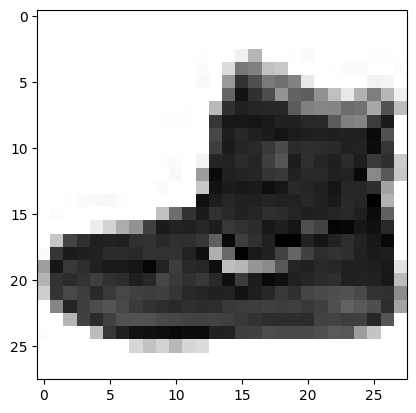

In [17]:
import matplotlib.pyplot as plt

X_sample = X_train[0].reshape(28, 28)
plt.imshow(X_sample, cmap= "binary")

In [26]:
class_names = ["T-shirt/top", "Trousers", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

y_train = y_train.astype(int)
y_test = y_test.astype(int)
class_names[y_train[0]]


'Ankle boot'

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

mlp_clf = MLPClassifier(hidden_layer_sizes=[300, 100], verbose=True,
                        early_stopping=True, random_state=42)
pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
#accuracy = pipeline.score(X_test, y_test)
y_pred = pipeline.predict(X_test)


Iteration 1, loss = 0.55394420
Validation score: 0.854833
Iteration 2, loss = 0.39017365
Validation score: 0.867500
Iteration 3, loss = 0.34572472
Validation score: 0.877500
Iteration 4, loss = 0.31541926
Validation score: 0.881167
Iteration 5, loss = 0.29351007
Validation score: 0.887167
Iteration 6, loss = 0.28459028
Validation score: 0.889167
Iteration 7, loss = 0.26775210
Validation score: 0.885500
Iteration 8, loss = 0.25610516
Validation score: 0.886667
Iteration 9, loss = 0.24488907
Validation score: 0.893167
Iteration 10, loss = 0.23915583
Validation score: 0.888500
Iteration 11, loss = 0.22290961
Validation score: 0.897167
Iteration 12, loss = 0.21925185
Validation score: 0.889667
Iteration 13, loss = 0.21249406
Validation score: 0.892167
Iteration 14, loss = 0.20374069
Validation score: 0.891333
Iteration 15, loss = 0.19557455
Validation score: 0.893833
Iteration 16, loss = 0.19099949
Validation score: 0.893667
Iteration 17, loss = 0.18445775
Validation score: 0.890333
Iterat

precision: 0.8944795807145483, recall: 0.8929, f1: 0.8933590782399813


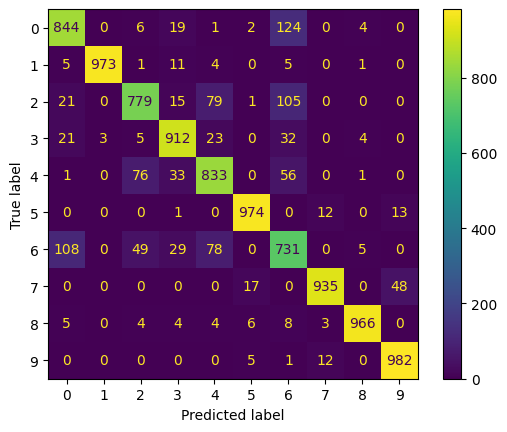

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay

prec = precision_score(y_pred=y_pred, y_true=y_test, average="macro")
recall = recall_score(y_pred=y_pred, y_true=y_test, average="macro")
f1 = f1_score(y_pred=y_pred, y_true=y_test, average="macro")

print(f"precision: {prec}, recall: {recall}, f1: {f1}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


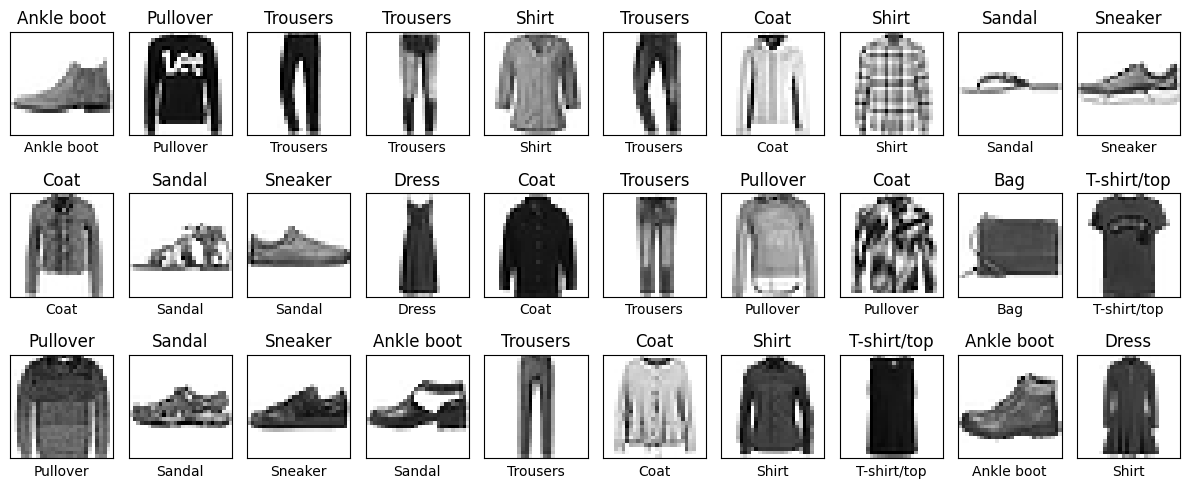

In [56]:
fig, ax = plt.subplots(3, 10, figsize=(12, 5), dpi=100)

for j in range(3):
    for i in range(10):
        sample = X_test[i + j*10].reshape(28, 28)
        ax[j][i].imshow(sample, cmap="binary")
        ax[j][i].set_title(class_names[y_test[i + j*10]])
        ax[j][i].set_xlabel(class_names[y_pred[i + j*10]])
        ax[j][i].set_xticks([])
        ax[j][i].set_yticks([])

plt.tight_layout()


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1000
           1       1.00      0.97      0.98      1000
           2       0.85      0.78      0.81      1000
           3       0.89      0.91      0.90      1000
           4       0.82      0.83      0.82      1000
           5       0.97      0.97      0.97      1000
           6       0.69      0.73      0.71      1000
           7       0.97      0.94      0.95      1000
           8       0.98      0.97      0.98      1000
           9       0.94      0.98      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

